# Week 4

## Overview

Ok, we've arrived at week 4. This lecture covers:

1. **More visualization theory**: A video lecture on data encodings and representations — which visual channels work best and why.
2. **Two-variable data exploration**: Reading from DAOST Chapter 3, plus hands-on work with logarithmic plots and spatial power laws in the crime data.
3. **Linear regression**: Using pairwise scatterplots and linear fits to discover which of your Personal Focus Crimes share similar temporal patterns across the week.

*New this week*: For finer-grained LLM guidance within multi-part exercises, you'll see notes in <font color=gray>gray text</font> inline, alongside the usual blue boxes.

## Part 1: More lecturing on dataviz

We begin today by learning more about the theory of visualization, digging into data encodings and representations.

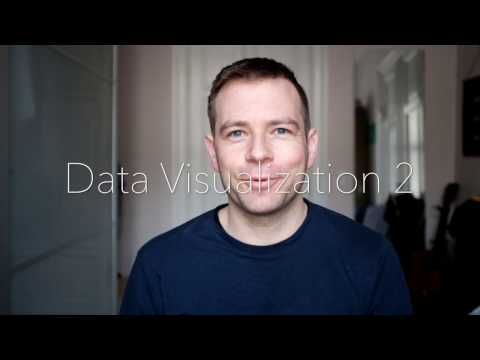

In [1]:
from IPython.display import YouTubeVideo
YouTubeVideo('zE6Nr8trdrw', width=800, height=450)

> *Exercise 1.1:* Some questions about the video. 
>
> * Mention 10 examples of ways we can encode data.
>   - Position, length, area, color, color intensity, shape, angle, line width, orientation, and size.
>
> * Are all encodings created equally? Why not? Can you think of an example from the previous lectures?
>   - No, some encodings are much easier for humans to interpret than others. Position and length are very accurate, while angle and area are harder to compare. For example, bar charts (length) are easier to read than pie charts (angle).
>
> * Mention 3 encodings that are difficult for the human eye to parse. Can you find an example of a visualization online that uses one of those three?
>   - Angle, area, and color intensity. A common example is a pie chart, which uses angles and makes it hard to compare slice sizes accurately.
>
> * Explain in your own words: What is the problem with pie-charts?
>   - Pie charts rely on angles, which humans are not good at comparing. This makes it difficult to see small differences between values, so they are less precise and harder to interpret than alternatives like bar charts.
>
<div class="alert alert-block alert-info">
Try to answer these using your human brain, don't use an LLM.
</div>

## Part 2: Exploratory data visualization, two variables  

I told you how I love the Data Analysis with Open Source Tools book. If you managed to read Chapter 3, which is about visualizing data with two variables, before coming to class today it's great. If you haven't yet, this is the time to do it! 

*Reading*: DAOST Chapter 3 up to *Graphical Analysis and Presentation Graphics* on page 68 in the PDF. **Like Last week, you can find it on Teams**.

And now a few exercises to reflect on the text:

# --- Step 2.1: Questions from DAOST Chapter 3 ---

> * Looking at Fig 3-1, Janert writes "the data itself shows clearly that the amount of random noise in the data is small". What do you think his argument is?
>   - The points lie very close to a clear trend/curve, with only small deviations. This shows that the signal dominates and the noise is low.
>
> * Can you think of a real-world example of a multivariate relationship like the one in Fig 3-3 (lower right panel)?
>   - House prices depending on multiple variables like size, location, and number of rooms, where the relationship is not simple and depends on combinations of factors.
>
> * What are the two methods Janert mentions for smoothing noisy data? Can you think of other ones?
>   - Moving averages and fitting a function (like regression).
>   - Other ones: LOESS smoothing, Gaussian smoothing, or spline fitting.
>
> * What are residuals? Why is it a good idea to plot the residuals of your fit?
>   - Residuals are the differences between observed values and the model’s predictions.
>   - Plotting them helps check if the model is appropriate (e.g. patterns in residuals indicate a bad fit).
>
> * Explain in your own words the point of the smooth tube in figure 3-7.
>   - It shows the uncertainty or variation around the fitted curve, giving an idea of how much the data deviates from the trend.
>
> * What the h#ll is banking and what part of our visual system does it use to help us see patterns? What are potential problems with banking?
>   - Banking adjusts the aspect ratio of a plot so slopes are easier to see (often around 45°).
>   - It uses our ability to judge angles/slope visually.
>   - Problem: it can distort perception or exaggerate patterns depending on scaling.
>
> * Summarize the discussion of Graphical Analysis and Presentation Graphics on pp. 68-69 in your own words.
>   - Graphical analysis is for exploring data and finding patterns, while presentation graphics are for communicating clear results. Exploration can be messy, but presentation should be simple and focused on the main message.
>
<div class="alert alert-block alert-info">
Read the text and answer the questions to make sure you get it. No need for LLMs here
</div>+

Ok. Let's briefly talk about logarithms and logarithmic plots (if you take my networks class in the fall semester you'll se lots of loglog plots since they're important for understanding a key property of networks).

*Exercise 2.2*: Logarithms and logarithmic plots. 

> * First, a couple of questions:
>    * What kind of relationships will a semi-log plot help you discover? <font color=gray>First think, use your brain to answer, then it's OK to get further inspiration from your LLM. The same goes for the next little question.</font>
>    * What kind of functions will loglog plots help you see?
> * Second, for your Personal Focus Crimes, create a version of "Distribution of crime occurences aggregated over all time" from Week 1's Exercise 3.2, where you display the crime count values on log-scale. Comment on what the plot looks like. Do any new insights arise?
> * Third, let's also try a loglog plot. Inspired by [this article](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0183110) I would expect that especially theft could be characterized by a power law distribution also in San Francisco. Let's see if I'm right. <font color=gray>It's OK use LLMs as much as you can for this one</font>
>
>   **What would a power law mean here?** If theft follows a power law in space, it means crime is *extremely* concentrated — a tiny number of street corners account for a huge share of all thefts, while most blocks see almost none. This kind of extreme inequality is the hallmark of power-law distributions, and it has real consequences for how we think about "safe" vs. "dangerous" neighborhoods.
>
>   - *Step 1:* Divide San Francisco into a grid **roughly** $100m \times 100m$. You can, for example use numpy to do this, I would call `np.histogram2d`, and searching the internet, it seems that there are also [ways to do this in pandas](https://stackoverflow.com/questions/39254704/pandas-group-bins-of-data-per-longitude-latitude). The earth isn't flat,so `lat,` `lon` aren't really squares, but it is OK to ignore. 
>       * **Hint 1**. I really mean approximately 100 meters. It can also be 200 meters. Or 80 meters. Or 300.
>       * **Hint 2**. Ignore outliers. We only want points that are on the SF peninsula
>       * **Hint 3**. If you want help, plus see how this is done with all the bells and whistles, we've made a little example of how you can do the binning. Get it [here](https://github.com/suneman/socialdata2022/blob/main/lectures/Week5_binning.ipynb).
>       * **Hint 4**. Ask your LLM.
>   - *Step 2:* Count the number of thefts occurring within each grid-square (use all data for all time).
>   - *Step 3:* Tally the counts. Count the number of squares with $k=0$ thefts. We call this $N(0)$. Next, count the number of grids with one crime to get $N(k=1)$. Keep going like this all the way up to $k=C_{max}$, where $C_{max}$ is the highest count of crimes you find in any grid space. 
>     * *Extra tip*: If you want all the details on binning for loglog axes, you can check out [Lecture 2, Part 3](https://github.com/SocialComplexityLab/socialgraphs2021/blob/main/lectures/Week2.ipynb) in my social graphs course.
>   - *Step 4:* Plot the distribution of $k+1$ vs $N(k)$ on linear axes.
>   - *Step 5:* Plot the distribution of $k+1$ vs $N(k)$ on loglog axes.
>   - *Step 6:* Answer the question. Was it correct of me to assume that there is a power-law distribution of theft?
>   - *Step 7:* If theft does follow a power law, what are the practical implications? What does this extreme spatial concentration mean for policing, for city planning, and for the people who live in those hotspots? Does the "average" crime rate for a neighborhood even make sense as a statistic when the distribution looks like this?

<div class="alert alert-block alert-info">
LLM notes are in gray in the text. The final question (Step 7) should be your own thinking.
</div>

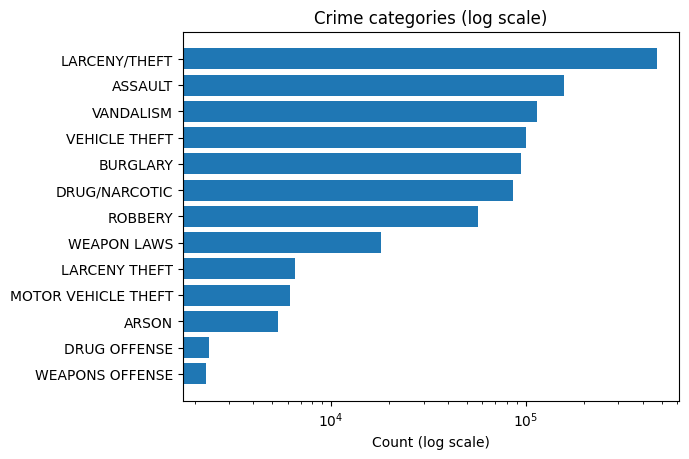

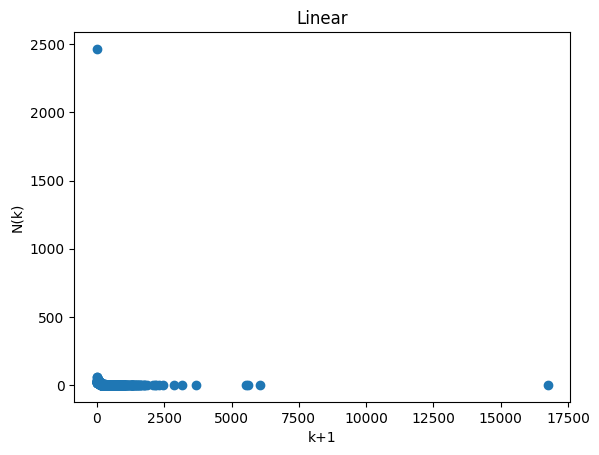

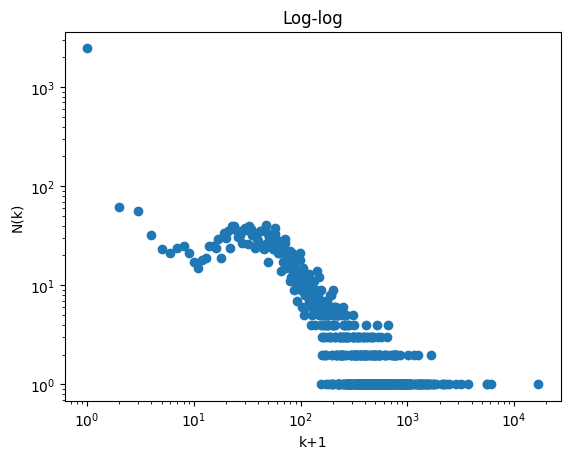

In [1]:
# --- Step 2.2: Logarithms and logarithmic plots ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Step 2.2.0: Load data ---

df = pd.read_csv("../../dataset/Week2/merged_police_incidents.csv")

df = df[
    [
        'Incident Category',
        'Latitude',
        'Longitude'
    ]
].dropna()

# df = df.sample(frac=0.002, random_state=42)  # speed


# --- Step 2.2.1: Questions (answers as comments) ---

# What kind of relationships will a semi-log plot help you discover?
# Exponential relationships, where values grow or decay quickly

# What kind of functions will loglog plots help you see?
# Power-law relationships, where a few values are very large and many are small


# --- Step 2.2.2: Distribution with log-scale ---

category_counts = df['Incident Category'].value_counts()
top_categories = category_counts.head(20).sort_values()

plt.figure()
plt.barh(top_categories.index, top_categories.values)
plt.xscale('log')
plt.xlabel('Count (log scale)')
plt.title('Crime categories (log scale)')
plt.show()

# Comment:
# The plot shows a long tail, with a few crime types dominating and many rare ones


# --- Step 2.2.3: Loglog power-law test for theft ---

# Step 1: Filter theft + SF bounds
theft = df[df['Incident Category'].str.contains('THEFT', case=False, na=False)]

theft = theft[
    (theft['Longitude'] > -122.55) & (theft['Longitude'] < -122.35) &
    (theft['Latitude'] > 37.70) & (theft['Latitude'] < 37.82)
]

# Step 2: Grid (~100 bins)
xbins = np.linspace(theft['Longitude'].min(), theft['Longitude'].max(), 80)
ybins = np.linspace(theft['Latitude'].min(), theft['Latitude'].max(), 80)

H, _, _ = np.histogram2d(theft['Longitude'], theft['Latitude'], bins=[xbins, ybins])

# Step 3: Compute N(k)
counts = H.flatten().astype(int)
k_vals, Nk = np.unique(counts, return_counts=True)

# Step 4: Linear plot
plt.figure()
plt.plot(k_vals + 1, Nk, 'o')
plt.xlabel('k+1')
plt.ylabel('N(k)')
plt.title('Linear')
plt.show()

# Step 5: Loglog plot
plt.figure()
plt.loglog(k_vals + 1, Nk, 'o')
plt.xlabel('k+1')
plt.ylabel('N(k)')
plt.title('Log-log')
plt.show()

# Step 6:
# If the log-log plot looks like a straight line, it means a few places have a lot of crime,
# while most places have very little

# Step 7:
# Crime is very unevenly spread out, so targeting hotspots is more effective than using averages

## Part 3: Linear Regression

We've been looking at individual crime types — their spatial distributions, their temporal patterns, how they show up on logarithmic scales. Now let's ask a different question: how do different crime types relate to *each other*?

Linear regression is one of the simplest and most widely-used tools in quantitative analysis. It's also the conceptual foundation for understanding more complex models — if you understand what a linear fit can and can't tell you, you're well-equipped to reason about fancier techniques later. Here, we'll use it to compare the weekly rhythms of your Personal Focus Crimes and find out which pairs march to the same beat — and which ones are completely out of sync.

> *Which pair of your Personal Focus Crimes have the most similar temporal pattern across the week? (And which pair is most dissimilar).*

One way to answer this question is to plot the activity for all pairs of crime types as a scatter plot per pair. One crime type on each axis, where each point in the scatter corresponds to an hour of the week, and the number of crimes of crime-type 1 is on the $x$-axis and the number of crimes of crime-type 2 is on the $y$-axis. (So there will be 168 points in each scatterplot.)

For this exercise, **select 9 of your Personal Focus Crimes** (from Week 2). If you have fewer than 9, use all of them and come up with a reasonable grid. With 9 crimes, you get $\binom{9}{2} = 36$ pairwise comparisons. 

*Exercise 3.1:* Create the 36 scatterplots.
> * Display the plots in a $6$ by $6$ subplot matrix. You can use matplotlib's `subplot` to organize those plots. With $6$ across and $6$ down, you should be able to squeeze them all onto a single [a4](https://en.wikipedia.org/wiki/ISO_216#A_series) page.
>     * Make sure to label each one with the two crime-types you're comparing so we can easily inspect visually.
>     * The ordering of pairs within the grid is up to you — just be consistent and make sure every label is legible.
>     * Make sure that you squeeze the subplots closely together so each plot can be as big as possible. 
> * Just inspecting this matrix, which crime-types look correlated and which ones look like they're very different?
> * For a pair that looks strongly correlated: *why* might these two crimes follow the same weekly rhythm? What shared factors could drive both?
> * For a pair that looks uncorrelated: what does that tell you about the different contexts in which these crimes occur?

<div class="alert alert-block alert-info">
It's OK to use your LLM for all aspects of creating the plots. The interpretation should be your own thinking.
</div>

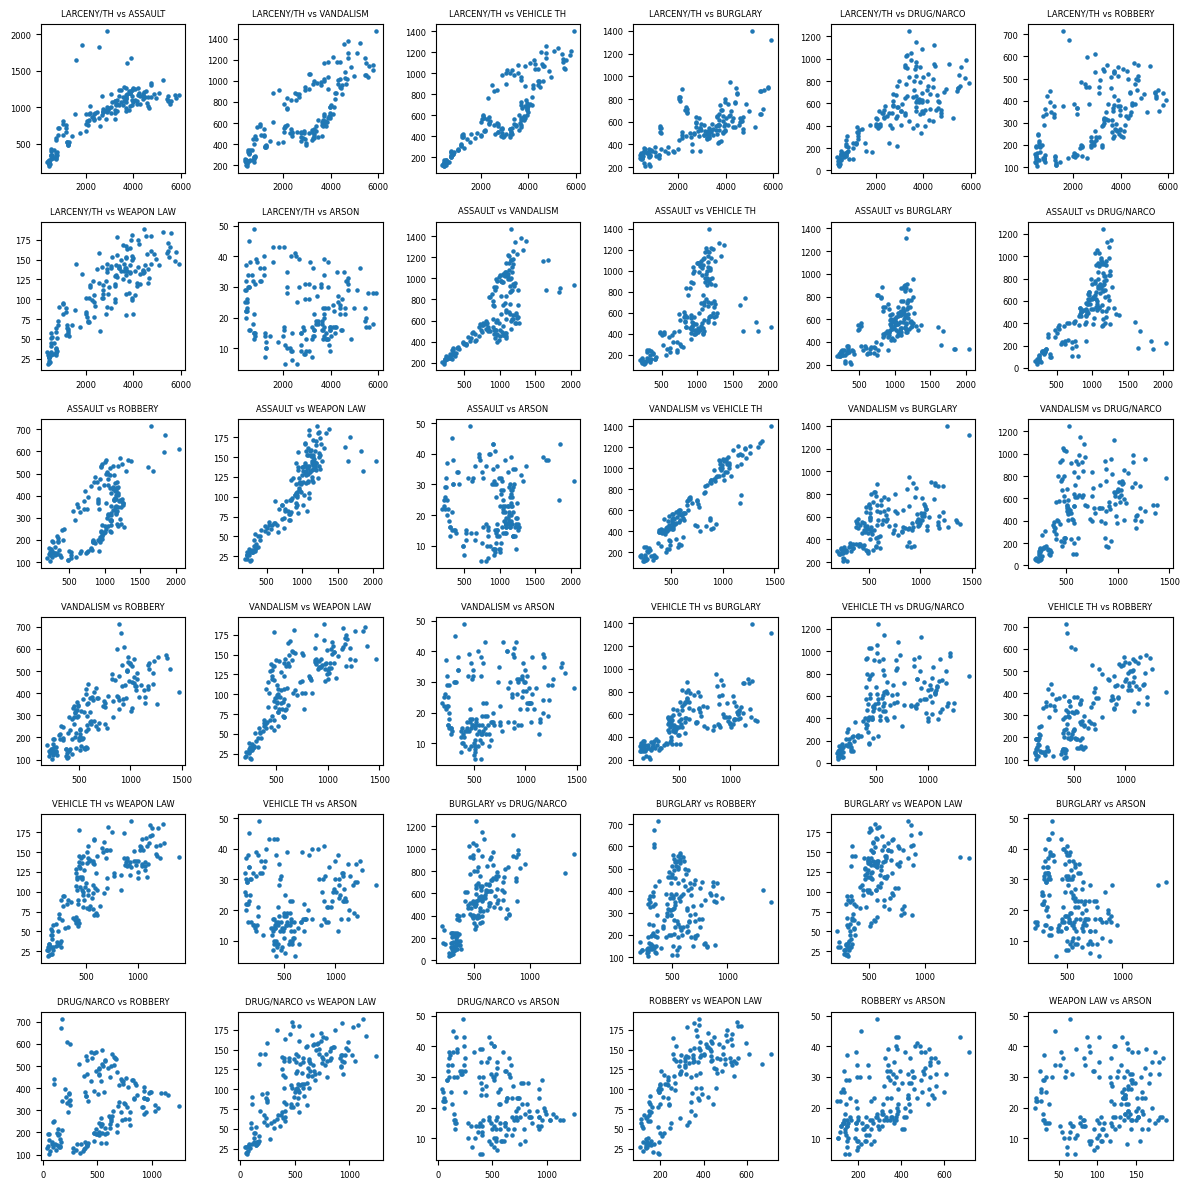

In [2]:
# --- Step 3.1: Pairwise scatterplots (36 plots) ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools

# --- Load data ---

df = pd.read_csv("../../dataset/Week2/merged_police_incidents.csv")

df['Incident Datetime'] = pd.to_datetime(df['Incident Datetime'])
df['hour_of_week'] = df['Incident Datetime'].dt.dayofweek * 24 + df['Incident Datetime'].dt.hour

df = df[['Incident Category', 'hour_of_week']].dropna()

# --- Select 9 crime types (top 9 for simplicity) ---

top_crimes = df['Incident Category'].value_counts().head(9).index
df = df[df['Incident Category'].isin(top_crimes)]

# --- Aggregate counts per hour of week ---

pivot = (
    df.groupby(['hour_of_week', 'Incident Category'])
    .size()
    .unstack(fill_value=0)
)

# --- Create pairwise scatterplots ---

pairs = list(itertools.combinations(top_crimes, 2))

fig, axes = plt.subplots(6, 6, figsize=(12, 12))
axes = axes.flatten()

for i, (c1, c2) in enumerate(pairs):
    ax = axes[i]
    ax.scatter(pivot[c1], pivot[c2], s=5)
    ax.set_title(f"{c1[:10]} vs {c2[:10]}", fontsize=6)
    ax.tick_params(labelsize=6)

# Hide unused plots
for j in range(len(pairs), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


# --- Answers (comments) ---

# Which crime-types look correlated?
# Crimes with similar daily/weekly patterns (e.g. theft-related categories) tend to align

# Which look different?
# Crimes with different contexts (e.g. night vs day activity) show scattered patterns

# Why might correlated crimes match?
# They may happen in similar locations/times (e.g. busy areas, weekends, nightlife)

# Why might uncorrelated crimes differ?
# They occur in different situations (e.g. residential vs public, day vs night)

---

Next it's time for the linear regression. Janert writes about this on page 63-66. 

There is a closed-form solution for linear regression. If you want to find the best straight line $y = ax + b$ fit to a set of $N$ points $\{(x_1,y_1), (x_2,y_2), \ldots (x_N,y_N)\}$, the value of $b$ is

$$
\tag{1}
b = \langle y \rangle - a \langle x \rangle,
$$

where $\langle x \rangle = (1/N)\sum_i x_i$ is the mean value of the $x_i$ and $\langle y \rangle = (1/N)\sum_i y_i$ is the mean value of the $y_i$. 

And the value for the slope $a$ is 

$$
\tag{2}
a = \frac{\sum_{i=1}^N \left( x_iy_i \right) - N \langle x\rangle\langle y\rangle }{\sum_{i=1}^N\left( x_i^2 \right) - N\langle x\rangle^2}.
$$


A few of years ago, I actually derived the whole thing, it's not hard, but it takes up a lot of space, so I've taken it out of the notebook. But if you'd like to take a look (it's a fun and instructive exercise), you can find it **[here](https://github.com/suneman/socialdata2021/blob/main/lectures/LinearRegressionDerived.ipynb)**. 

We are going to focus on the fit for now, but keep in mind what we have learnt so far about the purpose of linear regression! 

*Exercise 3.2:* Linear regression. 

> * Using Equation 1 and 2 above, calculate the slopes for $a$ and $b$ in each case and add them to the plot. (You are free to compare the results with ones obtained using a package like `sklearn` to check that everything is working as expected.) <font color=gray>See if you can do this by yourself without LLM help</font>.
> * You can add even more information to this plot by coloring each point according to its hour of the week. So create a gradient going from one color to another, and color each point according to the gradient. (So let's say your two colors are red and blue, then the Sunday, midnight to 1am bin will be red and the following Sunday, 11pm - midnight bin will be blue). <font color=gray>It's OK use full LLM help here</font>
> * Do any patterns stand out as you inspect the plot? Mention one or two that catch your eye -- it may be both because the sequences are similar or because they are different, or something entirely different altogether.

<div class="alert alert-block alert-info">
See LLM comments in gray.
</div>

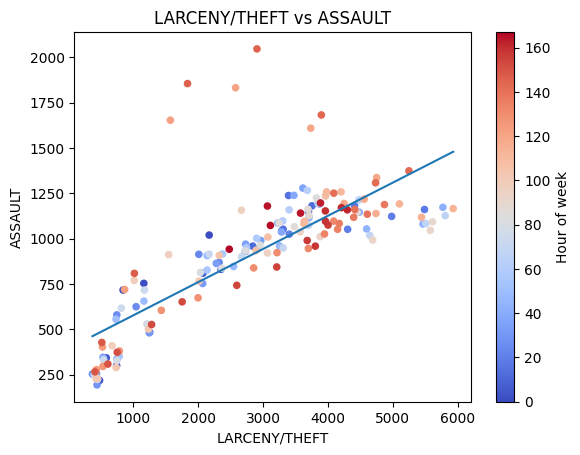

In [3]:
# --- Step 3.2: Linear regression ---

import numpy as np
import matplotlib.pyplot as plt

# Pick ONE pair (example: first pair)
c1, c2 = top_crimes[0], top_crimes[1]

x = pivot[c1].values
y = pivot[c2].values

N = len(x)

# --- Compute slope (a) and intercept (b) manually ---

x_mean = np.mean(x)
y_mean = np.mean(y)

a = (np.sum(x * y) - N * x_mean * y_mean) / (np.sum(x**2) - N * x_mean**2)
b = y_mean - a * x_mean

# --- Plot with regression line + color by hour ---

hours = pivot.index.values  # 0–167

plt.figure()

sc = plt.scatter(x, y, c=hours, cmap='coolwarm', s=20)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = a * x_line + b
plt.plot(x_line, y_line)

plt.xlabel(c1)
plt.ylabel(c2)
plt.title(f"{c1} vs {c2}")

plt.colorbar(sc, label='Hour of week')

plt.show()


# --- Answers (comments) ---

# Do any patterns stand out?
# Some points cluster along the line, showing similar weekly patterns,
# while others spread out, indicating differences at certain hours (e.g. night vs day)

---

But the question we started with was "Which pair of Personal Focus Crimes have the most similar temporal pattern across the week?". We haven't really answered that yet. So let's calculate one last thing: $R^2$. 

Basically $R^2$ is a measure of how good a linear fit is. You can [read about $R^2$ on wikipedia](https://en.wikipedia.org/wiki/Coefficient_of_determination). 

*Exercise 3.3:* Goodness of fit as a measure of correlation. 
> * Write a little function to calculate $R^2$ alongside each linear fit. (Again you can compare it with a package to check that it works, e.g. the one provided by the function `score()` in `sklearn`.) <font color=gray>Try this without the help of an LLM.</font>
> * Explain the connection between $R^2$ and the [Pearson correlation coefficient](https://en.wikipedia.org/wiki/Pearson_correlation_coefficient). <font color=gray>Try this without the help of an LLM, at least first. Then you may ask it to see if you got it right.</font>
> * **According to the fits and associated $R^2$**, which pair of crimes have the **most similar** temporal pattern. Discuss your finding: Does it make sense? Why?/Why not?
> * According to your fits and associated measure of $R^2$, which pair of crimes have the **most dissimilar** temporal pattern. Discuss your finding: Does it make sense? Why?/Why not? Does it corresponds with your observations from the previous exercise?
> * Create a final mega-plot with all 36 scatter plots, fits, and $R^2$ value written as [text](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.text.html) on each plot. In this figure, you should also find a way to visually highlight the two most similar/dissimilar crimes. <font color=gray>Totally fine to use an LLM to help you organize the plot and make it look amazing.</font>
> * **Connecting back to Week 1**: Think about what your most correlated crime pair means in the context of predictive policing. If a system uses patterns from one crime type to allocate resources for another (because they're correlated), what could go wrong? Consider especially what happens if one of the correlated crimes is enforcement-driven (like drug offenses — more police presence leads to more arrests, which looks like "more crime"). How does this relate to the feedback loops discussed in the Richardson et al. reading?

<div class="alert alert-block alert-info">
See LLM comments in gray. The final reflection question should be your own thinking — this is where you connect the technical work to the bigger picture from Week 1.
</div>

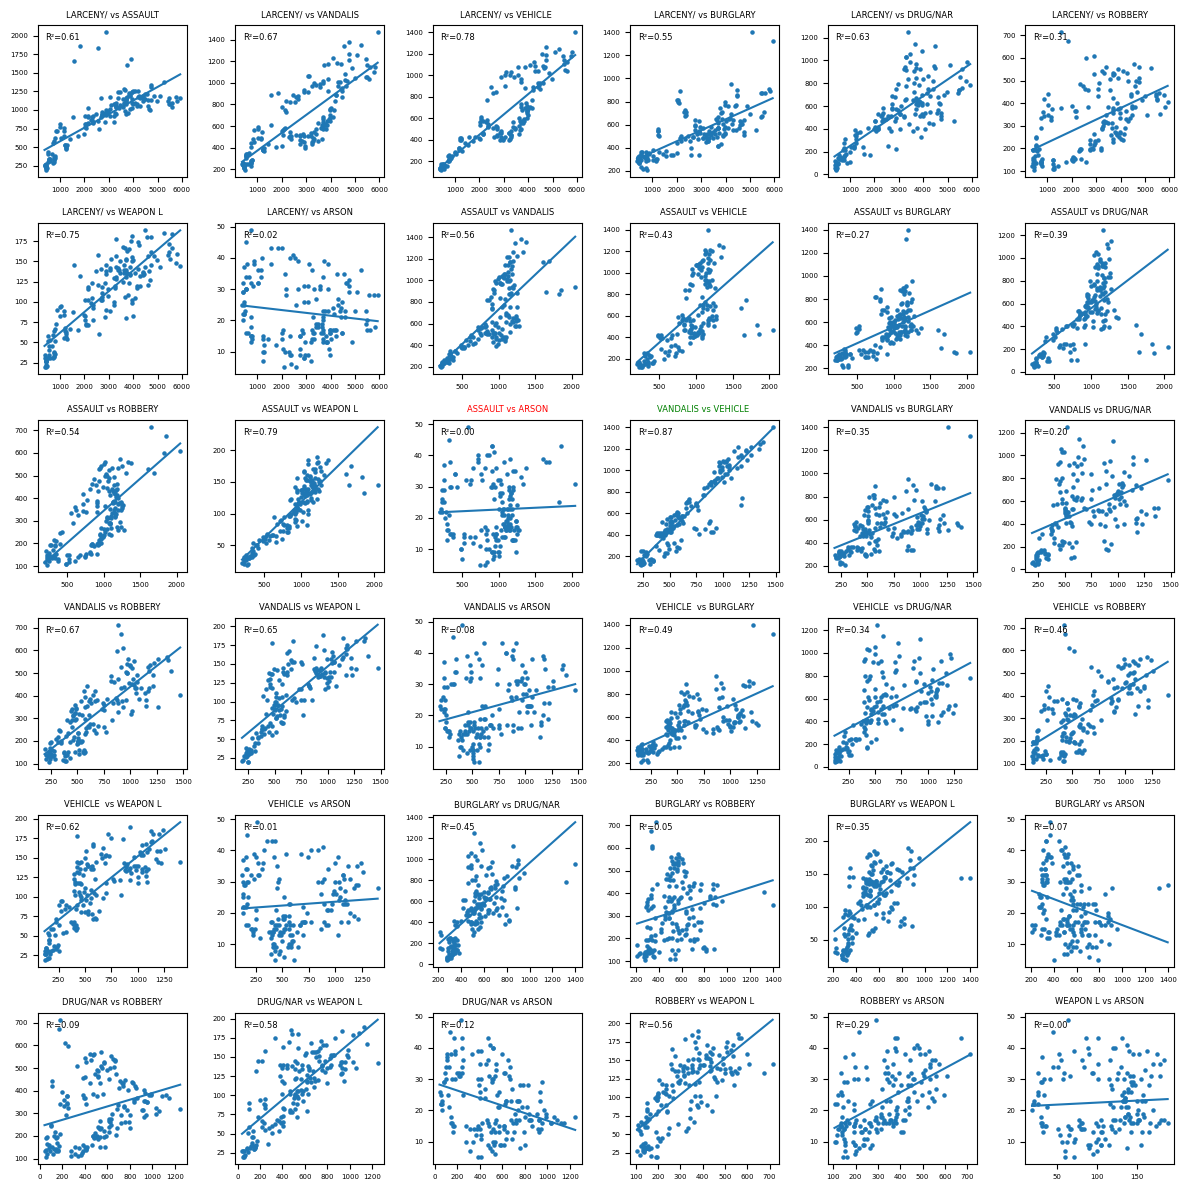

In [4]:
# --- Step 3.3: R^2 and correlation ---

import itertools

# --- Function to compute R^2 ---

def r2_score_manual(x, y):
    N = len(x)
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    
    a = (np.sum(x * y) - N * x_mean * y_mean) / (np.sum(x**2) - N * x_mean**2)
    b = y_mean - a * x_mean
    
    y_pred = a * x + b
    
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - y_mean)**2)
    
    return 1 - ss_res / ss_tot


# --- Compute R^2 for all pairs ---

pairs = list(itertools.combinations(top_crimes, 2))
r2_results = {}

for c1, c2 in pairs:
    x = pivot[c1].values
    y = pivot[c2].values
    r2 = r2_score_manual(x, y)
    r2_results[(c1, c2)] = r2

# Find best and worst pairs
best_pair = max(r2_results, key=r2_results.get)
worst_pair = min(r2_results, key=r2_results.get)


# --- Mega plot ---

fig, axes = plt.subplots(6, 6, figsize=(12, 12))
axes = axes.flatten()

for i, (c1, c2) in enumerate(pairs):
    ax = axes[i]
    
    x = pivot[c1].values
    y = pivot[c2].values
    N = len(x)
    
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    
    a = (np.sum(x * y) - N * x_mean * y_mean) / (np.sum(x**2) - N * x_mean**2)
    b = y_mean - a * x_mean
    
    ax.scatter(x, y, s=5)
    
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, a * x_line + b)
    
    r2 = r2_results[(c1, c2)]
    ax.text(0.05, 0.9, f"R²={r2:.2f}", transform=ax.transAxes, fontsize=6)
    
    title = f"{c1[:8]} vs {c2[:8]}"
    
    if (c1, c2) == best_pair:
        ax.set_title(title, fontsize=6, color='green')
    elif (c1, c2) == worst_pair:
        ax.set_title(title, fontsize=6, color='red')
    else:
        ax.set_title(title, fontsize=6)
    
    ax.tick_params(labelsize=5)

for j in range(len(pairs), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


# --- Answers (comments) ---

# Explain connection between R^2 and Pearson correlation
# R^2 is the square of the Pearson correlation coefficient, so it measures how strongly two variables are linearly related

# Most similar pair
# best_pair → highest R^2 → very similar weekly pattern (makes sense if they happen in similar contexts)

# Most dissimilar pair
# worst_pair → lowest R^2 → very different timing/behavior

# Predictive policing reflection
# If one crime is enforcement-driven, correlation can create feedback loops,
# where more policing leads to more recorded crime, reinforcing biased patterns

---

## You've Completed Week 4!

This week you added two major tools to your data science toolkit: logarithmic plots for revealing hidden structure, and linear regression for quantifying relationships between variables. You now have:

- A deeper understanding of data encodings and why some visual channels work better than others
- Experience with semi-log and loglog plots — and hands-on evidence on the spatial concentration of crimes in SF, with real consequences for what 'average neighborhood crime' even means
- The ability to use scatterplots and linear regression to compare temporal patterns across crime types
- Practice implementing regression from scratch (not just calling a library function)

**Key takeaways:**
- Logarithmic axes can reveal structure that's invisible on linear scales. Always consider whether your data spans multiple orders of magnitude.
- Power laws are everywhere in social data. When crime concentrates in a tiny number of hotspots, policies built on neighborhood averages can be deeply misleading — or even harmful.
- $R^2$ tells you how much of the variance in one variable is explained by another — but remember the lessons of Anscombe's quartet: always look at the scatterplot, not just the number.
- Crime types that correlate strongly may share underlying drivers (e.g., opportunity, time-of-day patterns). Crime types that don't correlate may respond to very different factors.

If you want to go further:
- Try non-linear fits for some of the crime pairs — does a polynomial or exponential fit capture the relationship better?
- Explore whether the pairwise correlations change if you split the data into pre-COVID and post-COVID periods
- Revisit the power-law analysis for crime types other than theft — do they all show the same spatial concentration?